# Problem Framing:

To what extent can UK road accident severity (Slight, Serious, Fatal) be predicted using spatio-temporal and environmental features, and can these predictions be used to identify reliable risk hotspots that generalise to future periods?

# Import the Libraries:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Basic exploration:

In [ ]:
df = pd.read_csv('accident_data.csv')
df.head()

,Index,Accident_Severity,Accident Date,Latitude,Light_Conditions,District Area,Longitude,Number_of_Casualties,Number_of_Vehicles,Road_Surface_Conditions,Road_Type,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,200701BS64157,Serious,05-06-2019,51.506187,Darkness - lights lit,Kensington and Chelsea,-0.209082,1,2,Dry,Single carriageway,Urban,Fine no high winds,Car
1,200701BS65737,Serious,02-07-2019,51.495029,Daylight,Kensington and Chelsea,-0.173647,1,2,Wet or damp,Single carriageway,Urban,Raining no high winds,Car
2,200701BS66127,Serious,26-08-2019,51.517715,Darkness - lighting unknown,Kensington and Chelsea,-0.210215,1,3,Dry,NaN,Urban,NaN,Taxi/Private hire car
3,200701BS66128,Serious,16-08-2019,51.495478,Daylight,Kensington and Chelsea,-0.202731,1,4,Dry,Single carriageway,Urban,Fine no high winds,Bus or coach (17 or more pass seats)
4,200701BS66837,Slight,03-09-2019,51.488576,Darkness - lights lit,Kensington and Chelsea,-0.192487,1,2,Dry,NaN,Urban,NaN,Other vehicle


In [ ]:
df.describe()

,Latitude,Longitude,Number_of_Casualties,Number_of_Vehicles
count,660654.000000,660653.000000,660679.000000,660679.000000
mean,52.553866,-1.431210,1.357040,1.831255
std,1.406922,1.383330,0.824847,0.715269
min,49.914430,-7.516225,1.000000,1.000000
25%,51.490690,-2.332291,1.000000,1.000000
50%,52.315641,-1.411667,1.000000,2.000000
75%,53.453452,-0.232869,1.000000,2.000000
max,60.757544,1.762010,68.000000,32.000000


In [ ]:
# Checking the Target column's unique values:
df['Accident_Severity'].unique()

array(['Serious', 'Slight', 'Fatal'], dtype=object)

In [ ]:
df.columns

Index(['Index', 'Accident_Severity', 'Accident Date', 'Latitude',
       'Light_Conditions', 'District Area', 'Longitude',
       'Number_of_Casualties', 'Number_of_Vehicles', 'Road_Surface_Conditions',
       'Road_Type', 'Urban_or_Rural_Area', 'Weather_Conditions',
       'Vehicle_Type'],
      dtype='object')

In [ ]:
df['District Area'].unique()

array(['Kensington and Chelsea', 'Westminster', 'Richmond upon Thames',
       'Hammersmith and Fulham', 'Hounslow', 'Tower Hamlets',
       'City of London', 'Southwark', 'Camden', 'Hackney', 'Islington',
       'Barnet', 'Brent', 'Haringey', 'Merton', 'Ealing', 'Enfield',
       'Greenwich', 'Newham', 'London Airport (Heathrow)', 'Hillingdon',
       'Waltham Forest', 'Redbridge', 'Barking and Dagenham', 'Bromley',
       'Havering', 'Croydon', 'Lambeth', 'Wandsworth', 'Sutton', 'Bexley',
       'Lewisham', 'Harrow', 'Kingston upon Thames', 'Barrow-in-Furness',
       'South Lakeland', 'Carlisle', 'Eden', 'Allerdale', 'Copeland',
       'Fylde', 'Blackpool', 'Wyre', 'Lancaster', 'Chorley',
       'West Lancashire', 'South Ribble', 'Preston',
       'Blackburn with Darwen', 'Hyndburn', 'Ribble Valley', 'Burnley',
       'Pendle', 'Rossendale', 'Wirral', 'Liverpool', 'Sefton',
       'Knowsley', 'St. Helens', 'Manchester', 'Salford', 'Tameside',
       'Stockport', 'Bolton', 'Wigan', '

In [ ]:
df['District Area'].value_counts()

District Area
Birmingham            13491
Leeds                  8898
Manchester             6720
Bradford               6212
Sheffield              5710
                      ...  
Berwick-upon-Tweed      153
Teesdale                142
Shetland Islands        133
Orkney Islands          117
Clackmannanshire         91
Name: count, Length: 422, dtype: int64

In [ ]:
# Shape of the dataset:
df.shape

(660679, 14)

In [ ]:
# checking Accident severity class value count for each category:
df['Accident_Severity'].value_counts()

Accident_Severity
Slight     563801
Serious     88217
Fatal        8661
Name: count, dtype: int64

### Note: Here we can see that it's a 3-Class Multiclass Classification Problem As 'Accident Severity' is our target column
### Additionally, the target column is highly imblalance

In [ ]:
df['Urban_or_Rural_Area'].value_counts()

Urban_or_Rural_Area
Urban          421663
Rural          238990
Unallocated        11
Name: count, dtype: int64

#### We can see there arre 11 unallocated locations, need to fix those

In [ ]:
# checking each column info in our dataset:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660679 entries, 0 to 660678
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Index                    660679 non-null  object 
 1   Accident_Severity        660679 non-null  object 
 2   Accident Date            660679 non-null  object 
 3   Latitude                 660654 non-null  float64
 4   Light_Conditions         660679 non-null  object 
 5   District Area            660679 non-null  object 
 6   Longitude                660653 non-null  float64
 7   Number_of_Casualties     660679 non-null  int64  
 8   Number_of_Vehicles       660679 non-null  int64  
 9   Road_Surface_Conditions  659953 non-null  object 
 10  Road_Type                656159 non-null  object 
 11  Urban_or_Rural_Area      660664 non-null  object 
 12  Weather_Conditions       646551 non-null  object 
 13  Vehicle_Type             660679 non-null  object 
dtypes: f

### Data Type Validation:
#### Since 'accident date' is in object format, need to convert those in a proper datetime format

In [ ]:
# Checking info for categorical features:
df.describe(include='O')

,Index,Accident_Severity,Accident Date,Light_Conditions,District Area,Road_Surface_Conditions,Road_Type,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
count,660679,660679,660679,660679,660679,659953,656159,660664,646551,660679
unique,421020,3,1461,5,422,5,5,3,8,16
top,2.01E+12,Slight,30-11-2019,Daylight,Birmingham,Dry,Single carriageway,Urban,Fine no high winds,Car
freq,239478,563801,704,484880,13491,447821,492143,421663,520885,497992


### Insights:
#### Index cokumn has unusual values'2.01E+12', Need to remove index column as it will not be important in our modeling
#### Slight seems to have the highest frequenc in our Accident severity column
#### In terms of light condition and Road type, Daylight & Dry surface recorded the most
#### Most of the accident occurs in urban areas and Single carrageway road conditions
#### Most Accident vehicle type from this record being Car

In [ ]:
# Checking for null value present in the dataset:
df.isnull().sum()

Index                          0
Accident_Severity              0
Accident Date                  0
Latitude                      25
Light_Conditions               0
District Area                  0
Longitude                     26
Number_of_Casualties           0
Number_of_Vehicles             0
Road_Surface_Conditions      726
Road_Type                   4520
Urban_or_Rural_Area           15
Weather_Conditions         14128
Vehicle_Type                   0
dtype: int64

In [ ]:
# Checking for Duplicate Records:
df_dup = df.duplicated()
num_dup = df_dup.sum()

print("Number of Duplicate Rows: ", num_dup)

Number of Duplicate Rows:  19


In [ ]:
# We can see there are 19 duplicated rows, so we need to drop those

In [ ]:
# Dropping duplicated values:
df = df.drop_duplicates()
df_dup = df.duplicated()
num_dup = df_dup.sum()

print("Number of Duplicate Rows: ", num_dup)

Number of Duplicate Rows:  0


In [ ]:
# Checking number of unique values in columns:
df.nunique()

Index                      421020
Accident_Severity               3
Accident Date                1461
Latitude                   511618
Light_Conditions                5
District Area                 422
Longitude                  529766
Number_of_Casualties           36
Number_of_Vehicles             19
Road_Surface_Conditions         5
Road_Type                       5
Urban_or_Rural_Area             3
Weather_Conditions              8
Vehicle_Type                   16
dtype: int64

In [ ]:
# Need to Handle categorical values in Preprocessing steps. i.e. strip spaces(if any), convert into all lowercase for better preprocessing and modelling, and unknown as nan

## Exploring and Visualizing the Target:

<Axes: xlabel='Accident_Severity'>

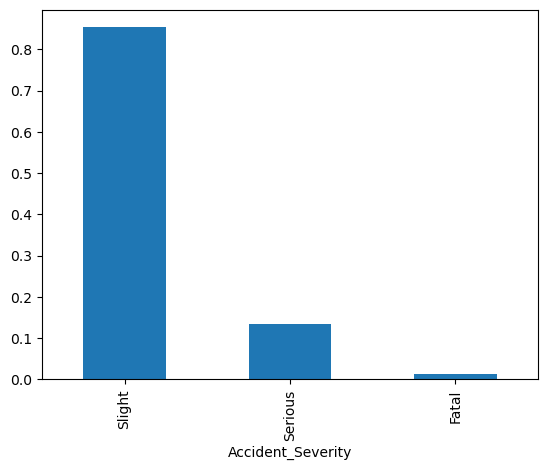

In [ ]:
df['Accident_Severity'].value_counts(normalize=True).plot.bar()

## Insights: accident_severity distribution (target) is highly imbalanced

Slight: 563,801 (85.34%)

Serious: 88,217 (13.35%)

Fatal: 8,661 (1.31%)

## Exploring the Features:

### Univariate Analysis:

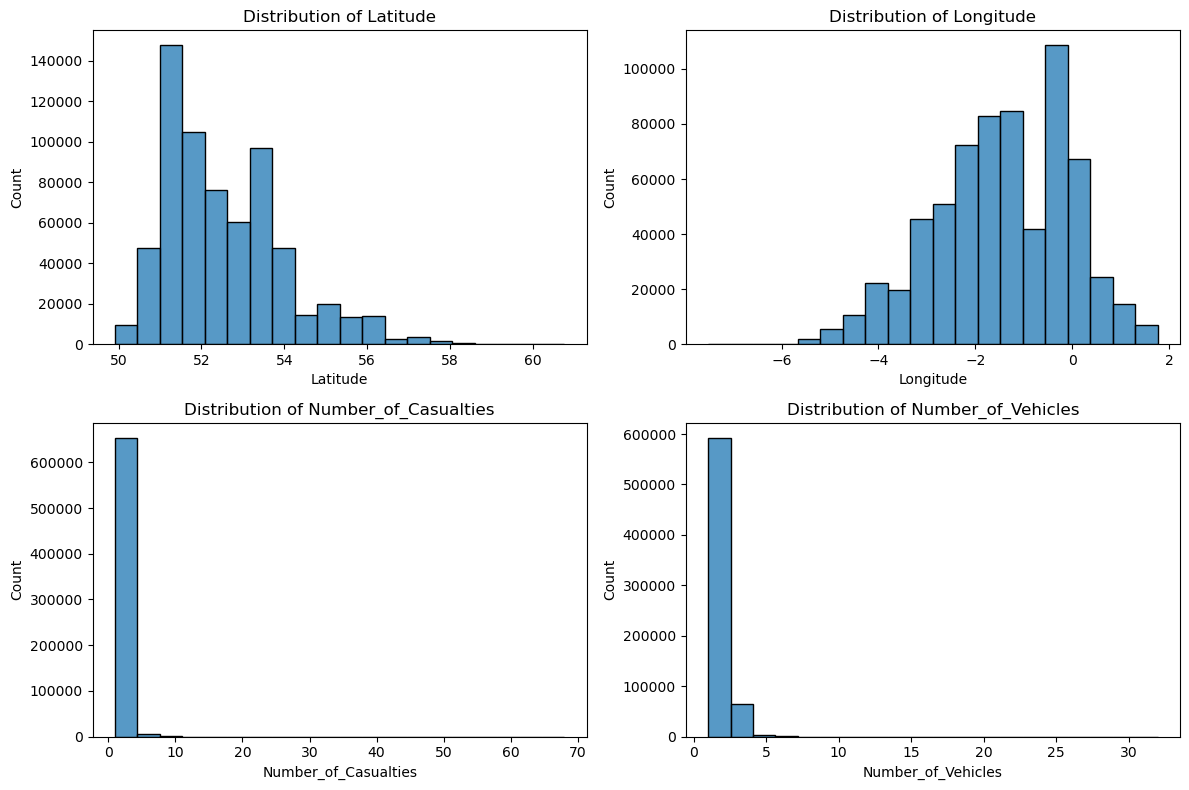

In [ ]:
# Numeric distributions:
num_cols = ["Latitude", "Longitude", "Number_of_Casualties", "Number_of_Vehicles"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), bins=20, kde=False, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


### Insights: Distribution of Number of Casualties

- Most accidents have 1 casualty.

- A smaller number have 2 or 3 casualties.

- Very few accidents have many casualties (large numbers are rare).

- Distribution is right-skewed, meaning most values are low

### Insights: Distribution of Number of Vehicles

- Most accidents involve 1 or 2 vehicles.

- Fewer accidents involve 3 or more vehicles.

- Accidents with many vehicles are very rare.

- This distribution is also right-skewed.

In [ ]:
# Skewness (useful for transformation/binning decisions)
skewness = df[["Number_of_Casualties", "Number_of_Vehicles"]].skew()
display(pd.DataFrame({"skewness": skewness}))

,skewness
Number_of_Casualties,7.081259
Number_of_Vehicles,1.802673


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 660660 entries, 0 to 660678
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Index                    660660 non-null  object 
 1   Accident_Severity        660660 non-null  object 
 2   Accident Date            660660 non-null  object 
 3   Latitude                 660635 non-null  float64
 4   Light_Conditions         660660 non-null  object 
 5   District Area            660660 non-null  object 
 6   Longitude                660634 non-null  float64
 7   Number_of_Casualties     660660 non-null  int64  
 8   Number_of_Vehicles       660660 non-null  int64  
 9   Road_Surface_Conditions  659934 non-null  object 
 10  Road_Type                656140 non-null  object 
 11  Urban_or_Rural_Area      660645 non-null  object 
 12  Weather_Conditions       646533 non-null  object 
 13  Vehicle_Type             660660 non-null  object 
dtypes: float6

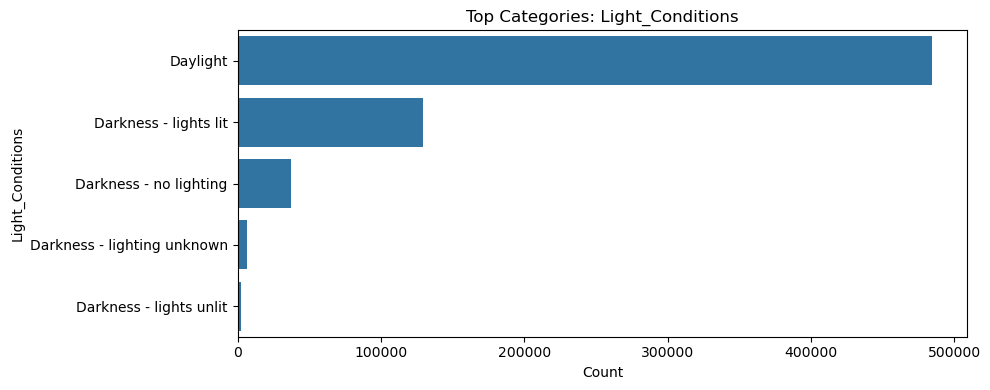

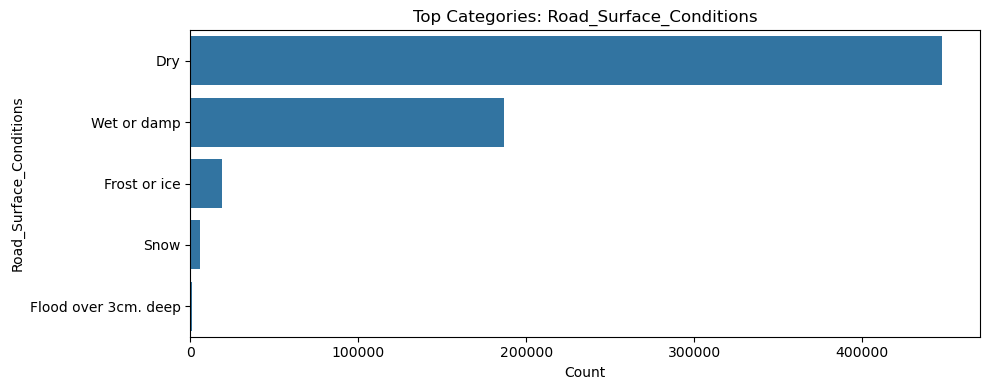

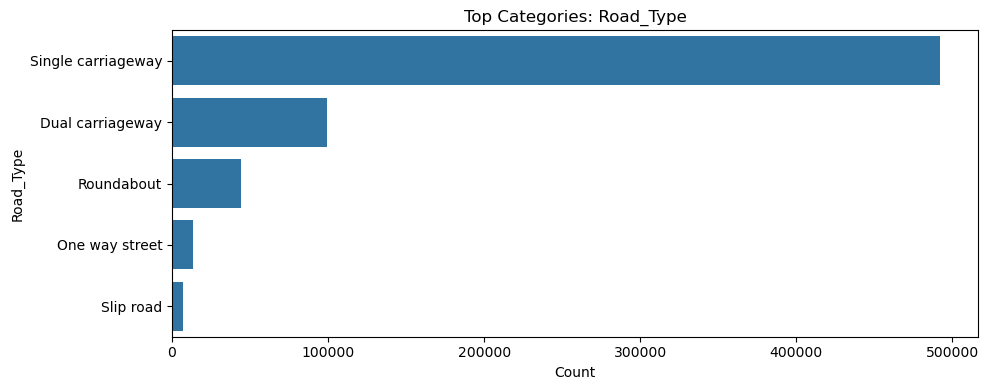

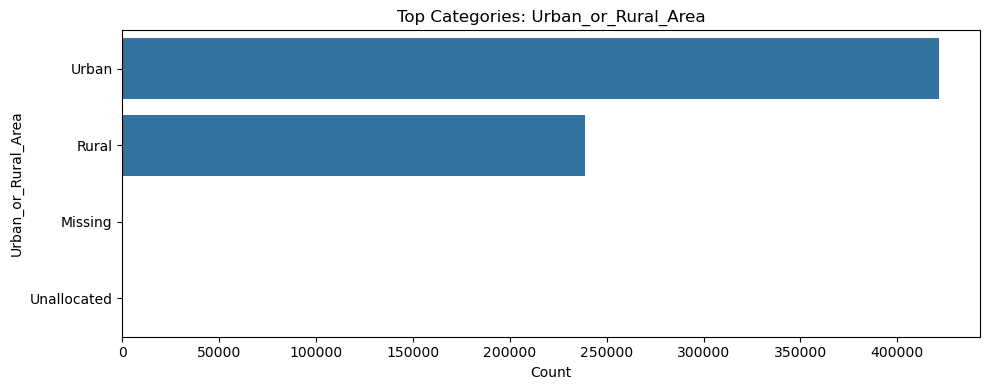

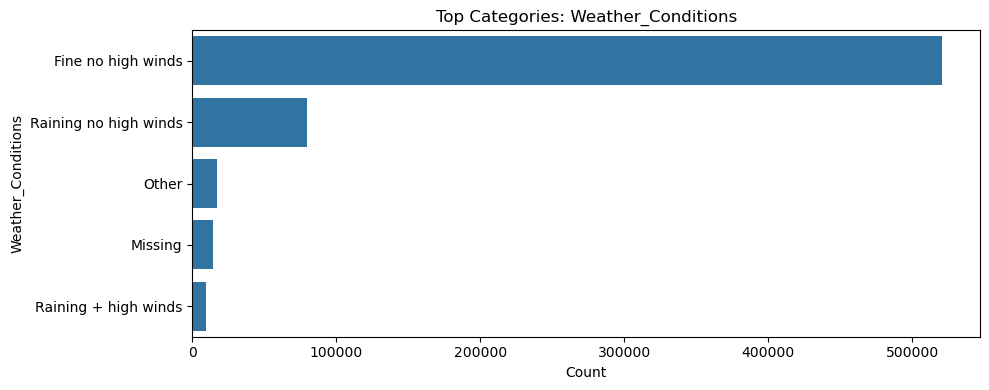

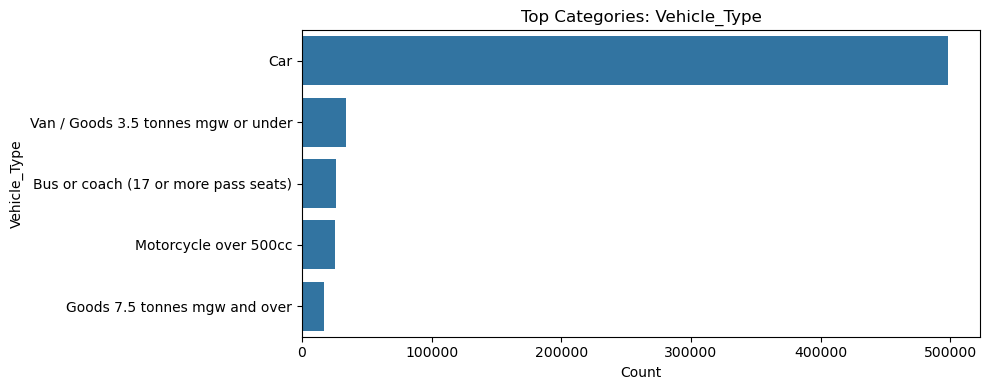

In [ ]:
# Categorical distributions (top levels)

cat_cols = [
    "Light_Conditions", "Road_Surface_Conditions", "Road_Type",
    "Urban_or_Rural_Area", "Weather_Conditions", "Vehicle_Type"
]

for col in cat_cols:
    plt.figure(figsize=(10,4))
    vc = df[col].fillna("Missing").value_counts().head(5) # Showing result for top 5 categories each
    sns.barplot(x=vc.values, y=vc.index)
    plt.title(f"Top Categories: {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

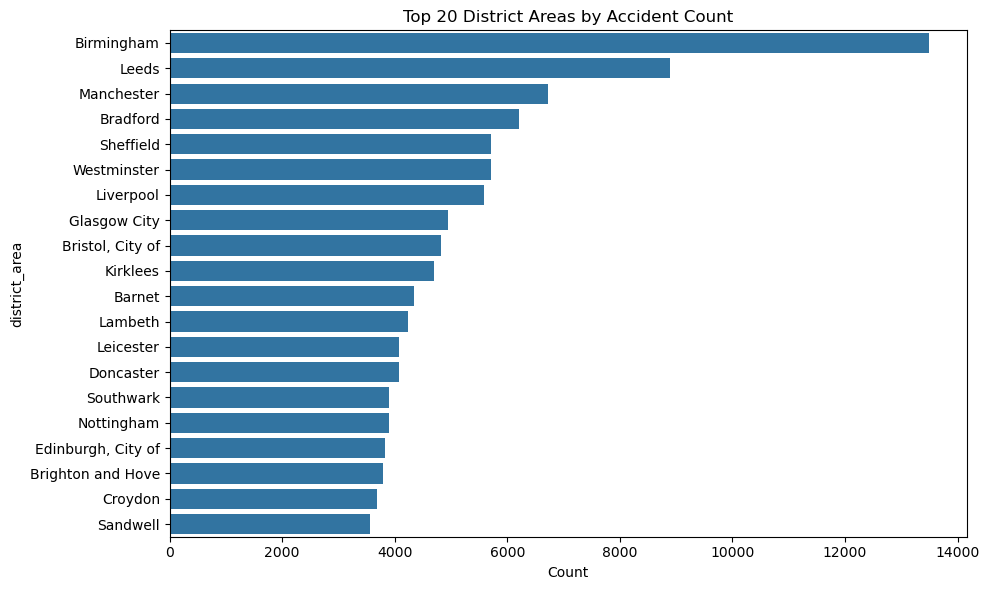

In [ ]:
# District area is high-cardinality → show top 20 out of 422 categories
plt.figure(figsize=(10,6))
top_districts = df["District Area"].value_counts().head(20)
sns.barplot(x=top_districts.values, y=top_districts.index)
plt.title("Top 20 District Areas by Accident Count")
plt.xlabel("Count")
plt.ylabel("district_area")
plt.tight_layout()
plt.show()

In [ ]:
# Renaming Index columndf = df.rename(columns={"index": "accident_id"})
df = df.rename(columns={"index": "accident_id"})

In [ ]:
df["Accident Date"] = pd.to_datetime(df["Accident Date"], dayfirst=True, errors="coerce")
df["Accident Date"].dtype

dtype('<M8[ns]')

In [ ]:
### creating time-derived variables for exploration:
import datetime as dt
df["acc_year"] = df["Accident Date"].dt.year
df["acc_month"] = df["Accident Date"].dt.month
df["acc_month_name"] = df["Accident Date"].dt.month_name()
df["acc_dayofweek"] = df["Accident Date"].dt.dayofweek
df["acc_day_name"] = df["Accident Date"].dt.day_name()

df[["Accident Date","acc_year","acc_month_name","acc_day_name"]].head()

,Accident Date,acc_year,acc_month_name,acc_day_name
0,2019-06-05,2019,June,Wednesday
1,2019-07-02,2019,July,Tuesday
2,2019-08-26,2019,August,Monday
3,2019-08-16,2019,August,Friday
4,2019-09-03,2019,September,Tuesday


<Figure size 1000x500 with 0 Axes>

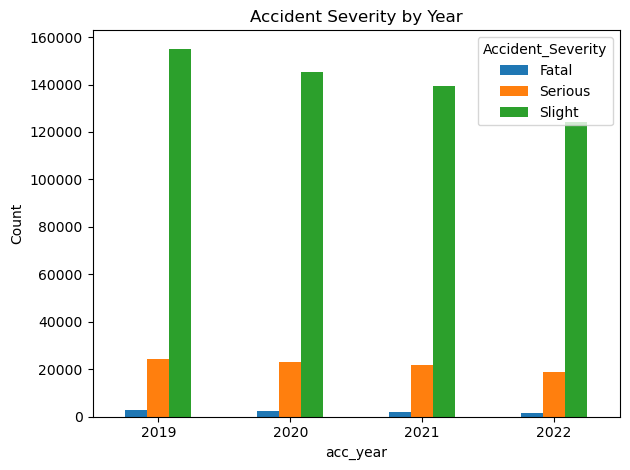

In [ ]:
# Plotting Accident Severity by Year:
sev_by_year = df.groupby("acc_year")["Accident_Severity"].value_counts().unstack(fill_value=0)
plt.figure(figsize=(10,5))
sev_by_year.plot(kind="bar")
plt.title("Accident Severity by Year")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Insights: we can see from the graph, accident count(Slight) decreases from 2019 to 2022.

### Seasonality check:

#### Monthly Accident Volume Visualize:

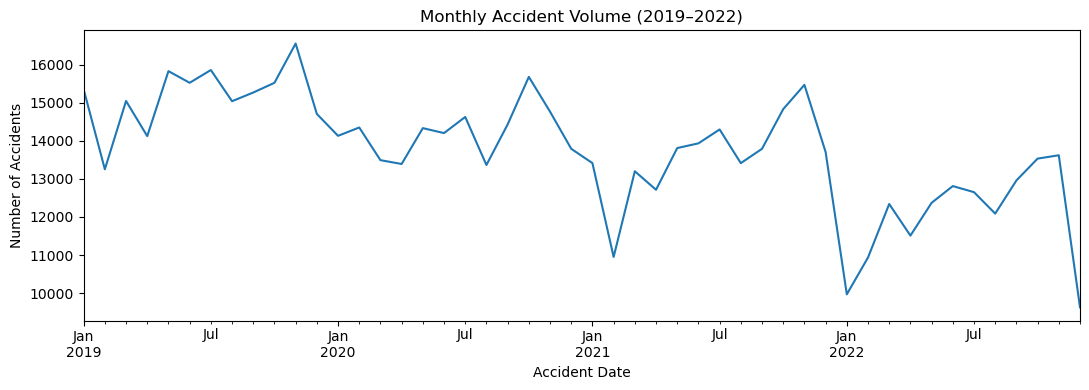

In [ ]:
monthly = df.set_index("Accident Date").resample("ME").size()
plt.figure(figsize=(11,4))
monthly.plot()
plt.title("Monthly Accident Volume (2019–2022)")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()

### Key Insights (2019–2022):

    - Overall downward trend: Accident volumes gradually declined from 2019 to 2022.

    - Seasonal pattern: Higher accident volumes typically occurred mid-year (around May–September), suggesting seasonal risk factors.


### Accident by Day of Week:

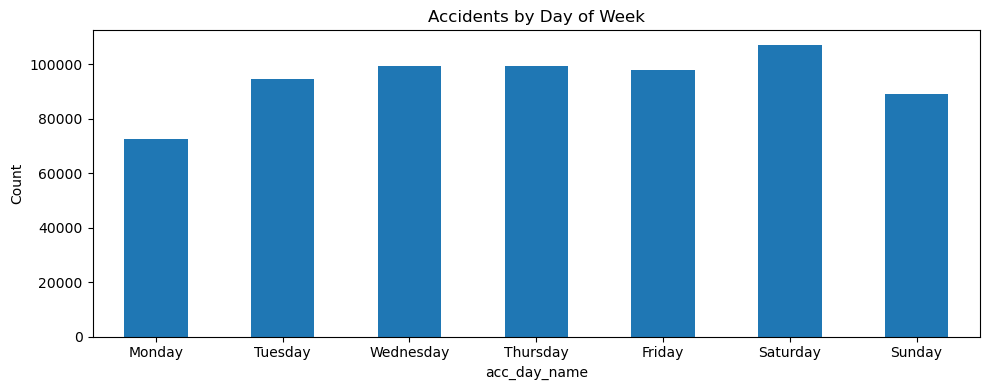

In [ ]:
dow = df["acc_day_name"].value_counts().reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
plt.figure(figsize=(10,4))
dow.plot(kind="bar")
plt.title("Accidents by Day of Week")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Key Insights:

    - Highest on Saturday: Accidents peak on Saturday, indicating elevated weekend risk.

    - Midweek high volume: Wednesday and Thursday also show consistently high accident counts.

    - Lowest on Monday: Monday has the fewest accidents, suggesting lower traffic risk at the start of the week.

### Accident by Months(All Years):

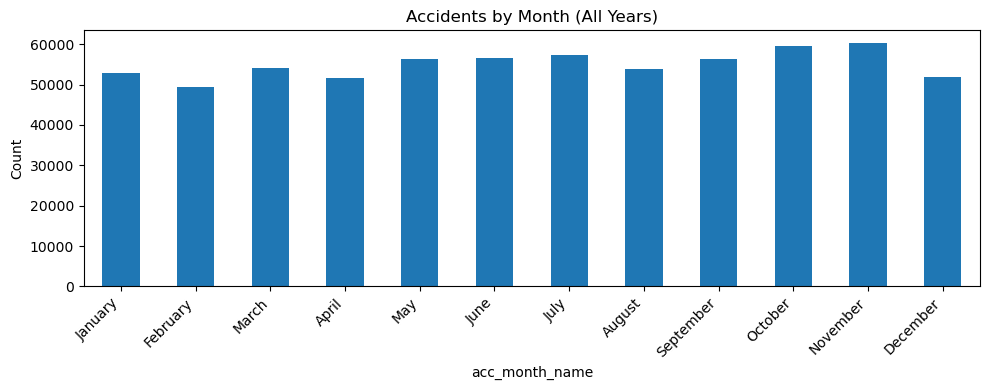

In [ ]:
mon = df["acc_month_name"].value_counts().reindex([
    "January","February","March","April","May","June","July","August","September","October","November","December"
])
plt.figure(figsize=(10,4))
mon.plot(kind="bar")
plt.title("Accidents by Month (All Years)")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Key Insights:

    -Peak months: October and November show the highest accident volumes, followed closely by July and September.

    -Lowest month: February has the lowest accident count.

    -Mid–late year rise: Accident frequency generally increases from May through November.

## Bivariate Analysis:

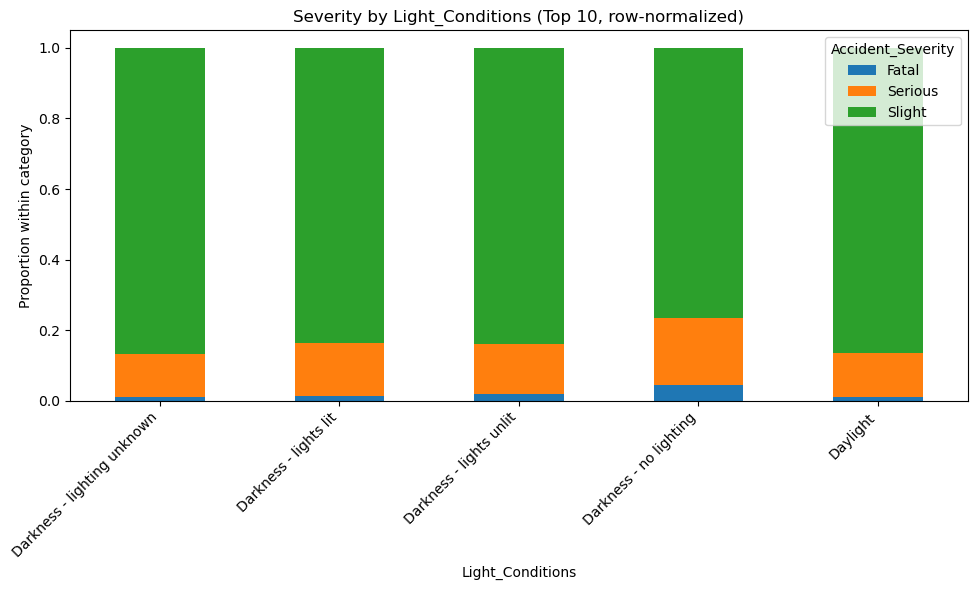

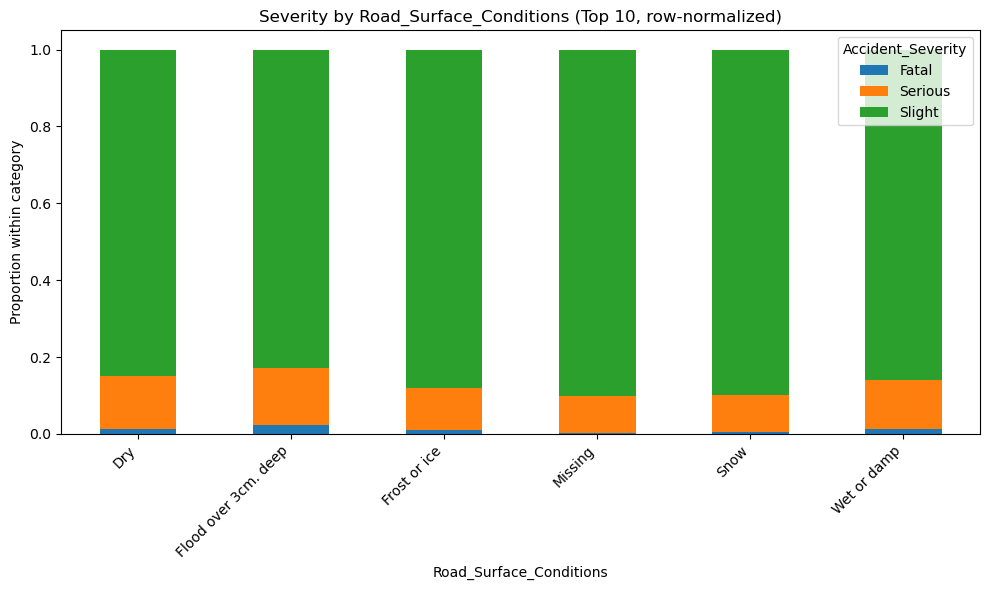

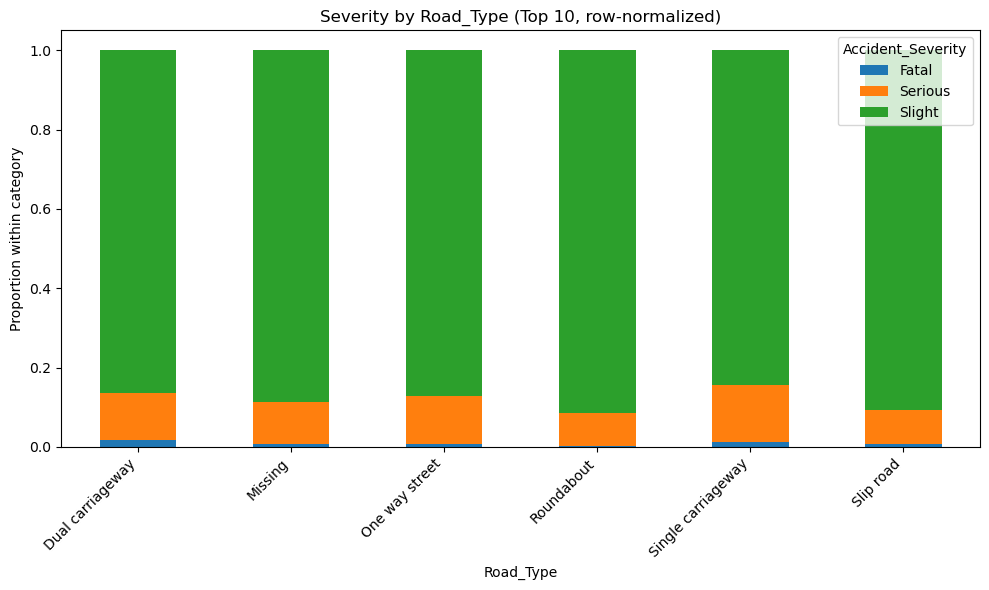

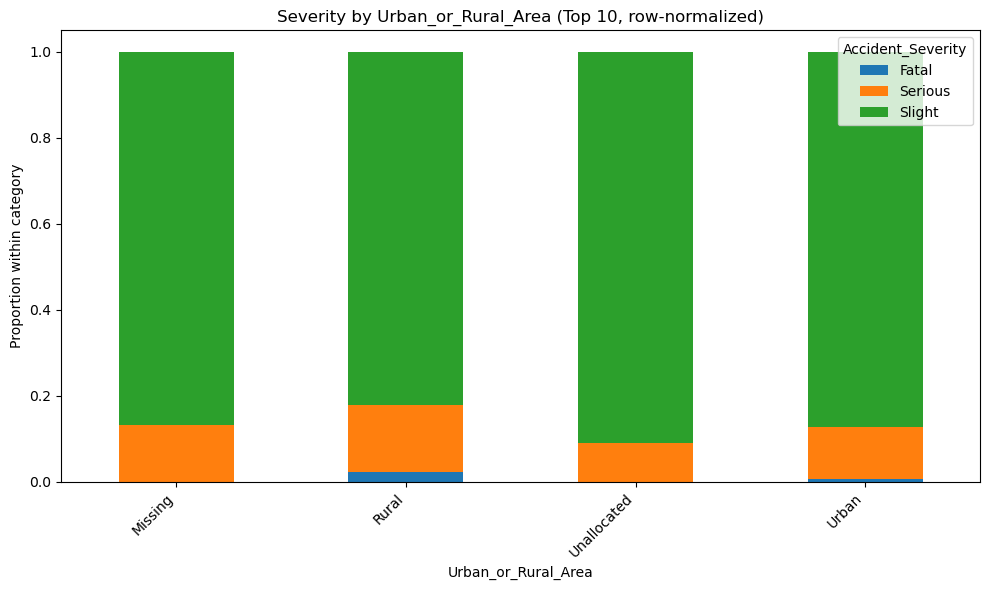

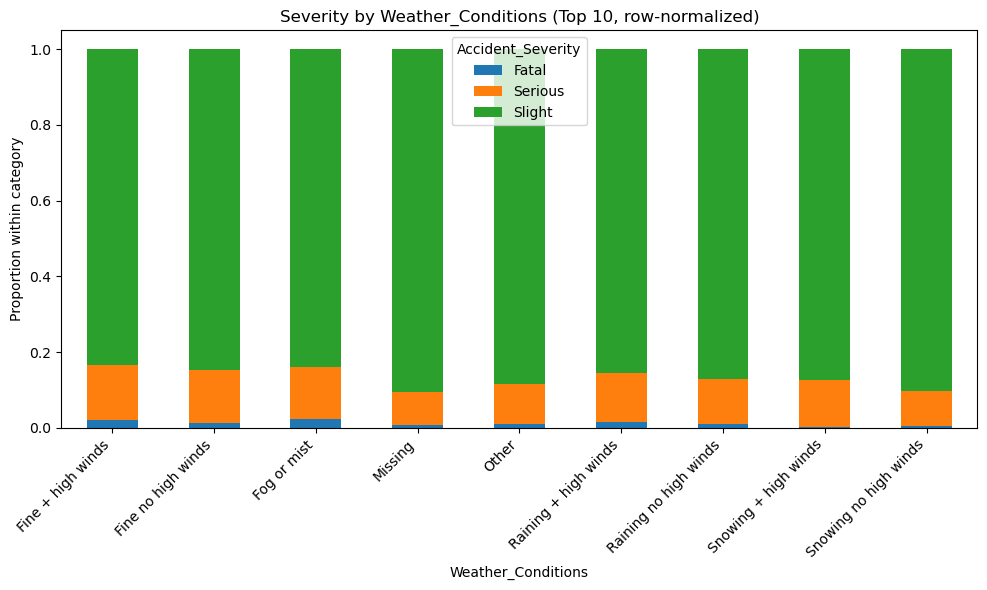

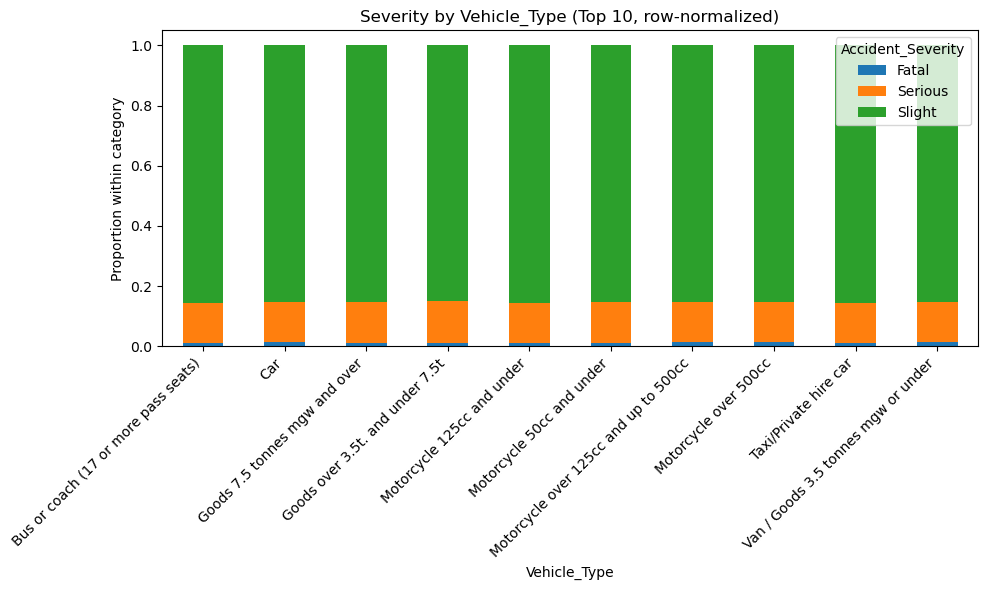

In [ ]:
# severity (Target) vs categorical features:
def severity_stackbar(cat_col, top_n=10):
    tmp = df[[cat_col, "Accident_Severity"]].copy()
    tmp[cat_col] = tmp[cat_col].fillna("Missing")
    top = tmp[cat_col].value_counts().head(top_n).index
    tmp = tmp[tmp[cat_col].isin(top)]
    ct = pd.crosstab(tmp[cat_col], tmp["Accident_Severity"], normalize="index")
    ct.plot(kind="bar", stacked=True, figsize=(10,6))
    plt.title(f"Severity by {cat_col} (Top {top_n}, row-normalized)")
    plt.ylabel("Proportion within category")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

for col in cat_cols:
    severity_stackbar(col, top_n=10)

### Checking Correlation:

In [ ]:
df_corr = df[num_cols].corr()
df_corr

,Latitude,Longitude,Number_of_Casualties,Number_of_Vehicles
Latitude,1.000000,-0.398117,0.032198,-0.040028
Longitude,-0.398117,1.000000,-0.040405,0.014717
Number_of_Casualties,0.032198,-0.040405,1.000000,0.228889
Number_of_Vehicles,-0.040028,0.014717,0.228889,1.000000


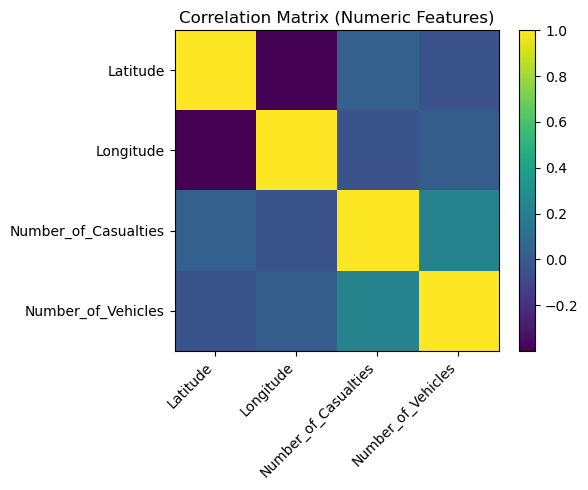

In [ ]:
# Visualizing using correlation matrix:
plt.figure(figsize=(6,5))
plt.imshow(df_corr, aspect="auto")
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Correlation Matrix (Numeric Features)")
plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
## Insights: No Significant correlation between numeric features
# No Multicollinearity- which means two or more independent variables are not highly correlated to each other
# If it does, then it will lead to instability in our model and lead to overfitting

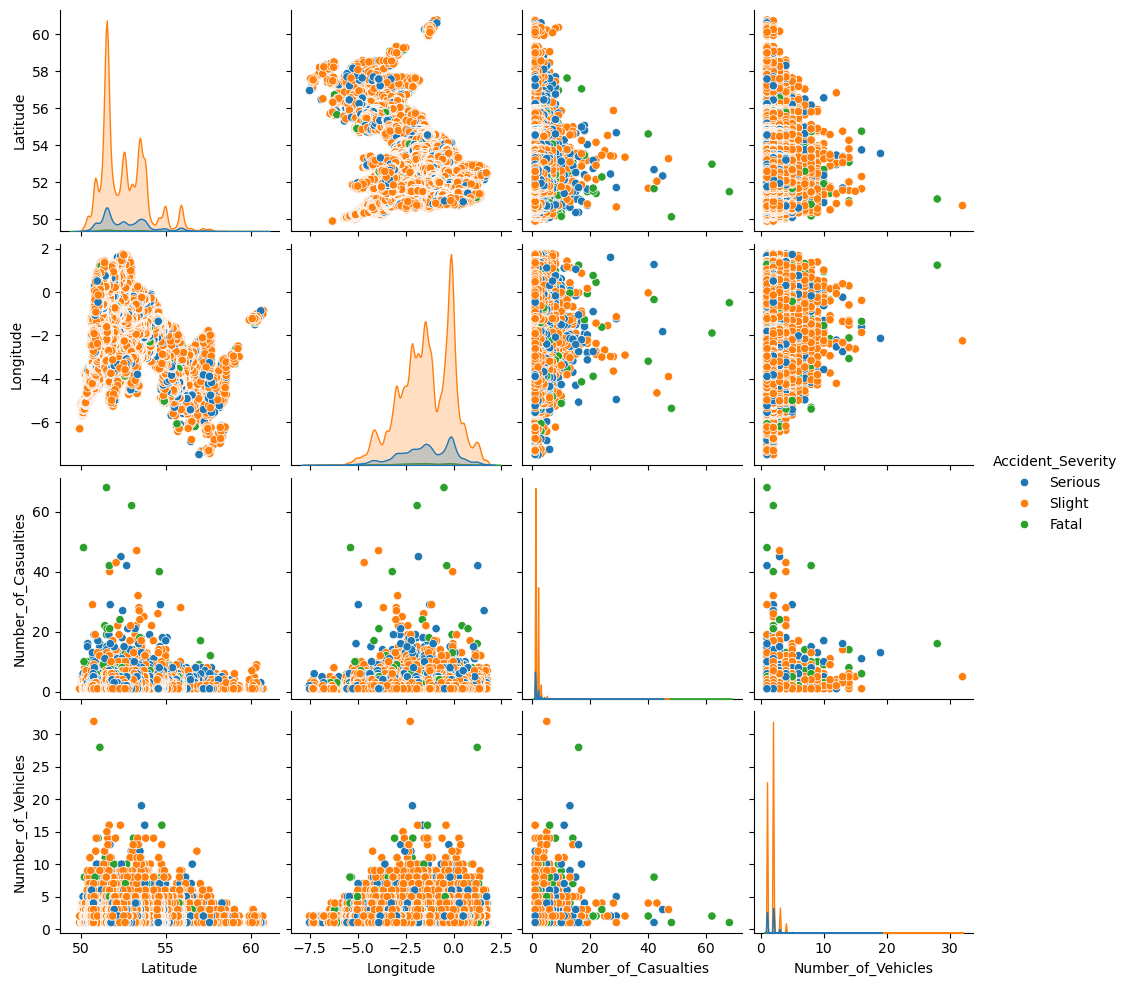

In [ ]:
sns.pairplot(df.drop('Index', axis=1), hue="Accident_Severity")

### Insights from pair plot:

1) Strong class imbalance in Accident_Severity

- “Slight” dominates almost every panel; “Fatal” is rare.

2) Geography is multi-modal (and severity isn’t cleanly separable by location)

- Latitude and Longitude form clear geographic clusters (multi-peak density on diagonals; the Lat–Long scatter resembles a map-like footprint).
- Severity colors heavily overlap across regions—no obvious “fatal-only” geographic pocket in these features alone.

3) Number_of_Casualties is extremely right-skewed (with a long-tail of outliers)

- Most accidents sit near very low casualty counts, but there are rare events with very large values.

4) Number_of_Vehicles is also right-skewed with discrete “bands”

- Huge concentration around 1–3 vehicles, and a small number of high-vehicle outliers (10+ up to ~30).

5) Casualties vs Vehicles: weak-to-moderate relationship, with important exceptions

- The Casualties–Vehicles panel shows a dense cloud at low values and no strong linear trend.

- High-casualty points can occur even with relatively few vehicles (suggesting scenarios like single-vehicle high-impact events, etc.)


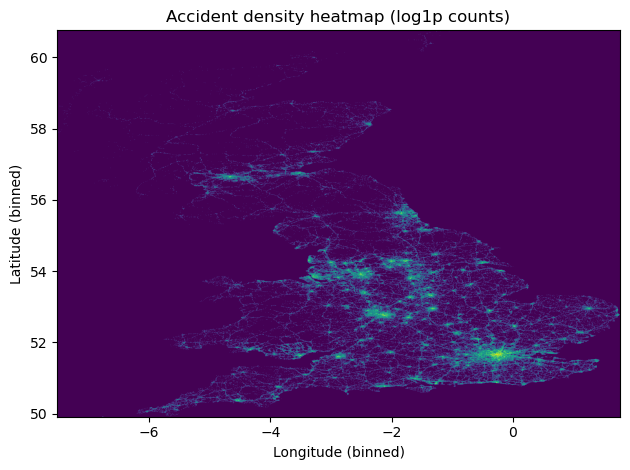

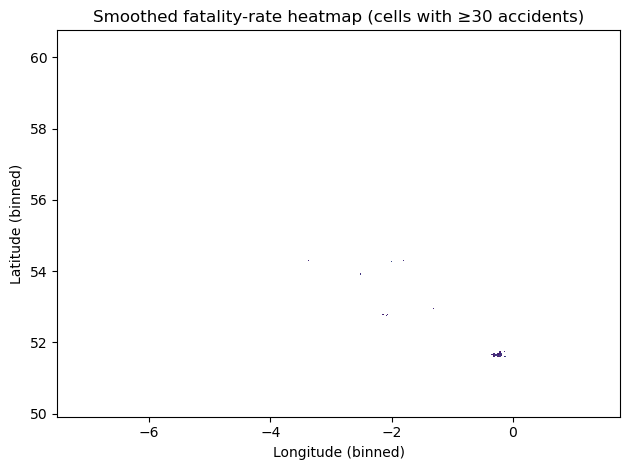

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, zipfile

# 2) Geo heatmaps (density + smoothed fatal rate)
geo = df[["Latitude", "Longitude", "Accident_Severity"]].dropna()
bin_size = 0.01
geo["lat_bin"] = np.floor(geo["Latitude"].astype(float)/bin_size)*bin_size
geo["lon_bin"] = np.floor(geo["Longitude"].astype(float)/bin_size)*bin_size

grid = geo.groupby(["lat_bin", "lon_bin"]).agg(
    accidents=("Accident_Severity", "size"),
    fatal=("Accident_Severity", lambda x: (x=="Fatal").sum())
).reset_index()

p_global = float((df["Accident_Severity"]=="Fatal").mean())
m = 50.0
alpha, beta = p_global*m, (1.0-p_global)*m
grid["fatal_rate_smooth"] = (grid["fatal"] + alpha) / (grid["accidents"] + alpha + beta)

# Density pivot
density = grid.pivot_table(index="lat_bin", columns="lon_bin", values="accidents", fill_value=0).sort_index().sort_index(axis=1)
lat_vals = density.index.values
lon_vals = density.columns.values

# Use extent to approximate coordinates on axes
extent = [lon_vals.min(), lon_vals.max()+bin_size, lat_vals.min(), lat_vals.max()+bin_size]

plt.figure()
plt.imshow(np.log1p(density.values), origin="lower", aspect="auto", extent=extent)
plt.xlabel("Longitude (binned)")
plt.ylabel("Latitude (binned)")
plt.title("Accident density heatmap (log1p counts)")
plt.tight_layout()

# Smoothed fatal rate heatmap with stability filter
stable = grid[grid["accidents"] >= 30]
risk = stable.pivot_table(index="lat_bin", columns="lon_bin", values="fatal_rate_smooth").sort_index().sort_index(axis=1)

# Align to same bins as density for consistent extent
risk = risk.reindex(index=lat_vals, columns=lon_vals)

plt.figure()
plt.imshow(risk.values, origin="lower", aspect="auto", extent=extent)
plt.xlabel("Longitude (binned)")
plt.ylabel("Latitude (binned)")
plt.title("Smoothed fatality-rate heatmap (cells with ≥30 accidents)")
plt.tight_layout()

#paths.extend([density_path, risk_path])

# Data Preprocessing:

### Drop rows with missing Target(safe before train-test split)

In [ ]:
missing_target_col = df['Accident_Severity'].isnull().sum()
print(missing_target_col)

0


In [ ]:
# So we can see there are no missing target rows

In [ ]:
# Dropping Index and Accident Date from the dataset because we dont need those columns
df_copy = df.drop(columns=['Index','Accident Date'])
df_copy.head()

,Accident_Severity,Latitude,Light_Conditions,District Area,Longitude,Number_of_Casualties,Number_of_Vehicles,Road_Surface_Conditions,Road_Type,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type,acc_year,acc_month,acc_month_name,acc_dayofweek,acc_day_name
0,Serious,51.506187,Darkness - lights lit,Kensington and Chelsea,-0.209082,1,2,Dry,Single carriageway,Urban,Fine no high winds,Car,2019,6,June,2,Wednesday
1,Serious,51.495029,Daylight,Kensington and Chelsea,-0.173647,1,2,Wet or damp,Single carriageway,Urban,Raining no high winds,Car,2019,7,July,1,Tuesday
2,Serious,51.517715,Darkness - lighting unknown,Kensington and Chelsea,-0.210215,1,3,Dry,NaN,Urban,NaN,Taxi/Private hire car,2019,8,August,0,Monday
3,Serious,51.495478,Daylight,Kensington and Chelsea,-0.202731,1,4,Dry,Single carriageway,Urban,Fine no high winds,Bus or coach (17 or more pass seats),2019,8,August,4,Friday
4,Slight,51.488576,Darkness - lights lit,Kensington and Chelsea,-0.192487,1,2,Dry,NaN,Urban,NaN,Other vehicle,2019,9,September,1,Tuesday


### Checking for duplicates:

In [ ]:
df_copy[df_copy.duplicated()]

,Accident_Severity,Latitude,Light_Conditions,District Area,Longitude,Number_of_Casualties,Number_of_Vehicles,Road_Surface_Conditions,Road_Type,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type,acc_year,acc_month,acc_month_name,acc_dayofweek,acc_day_name
18398,Slight,51.474388,Daylight,Wandsworth,-0.176344,1,2,Dry,Single carriageway,Urban,Fine no high winds,Car,2019,4,April,4,Friday
27814,Slight,53.770651,Daylight,Preston,-2.705480,1,2,Dry,Single carriageway,Urban,Fine no high winds,Car,2019,4,April,3,Thursday
30232,Slight,53.634450,Darkness - no lighting,Chorley,-2.594165,1,1,Wet or damp,Dual carriageway,Rural,Raining no high winds,Car,2019,12,December,6,Sunday
30904,Slight,53.338433,Daylight,Wirral,-3.021683,1,2,Wet or damp,Dual carriageway,Rural,Raining no high winds,Car,2019,10,October,1,Tuesday
40515,Slight,53.550845,Darkness - lights lit,Rochdale,-2.182447,1,2,Dry,Dual carriageway,Urban,Fine no high winds,Car,2019,2,February,4,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
596536,Slight,52.966727,Daylight,Rushcliffe,-0.958895,1,2,Dry,Roundabout,Rural,Fine no high winds,Car,2022,7,July,6,Sunday
602608,Slight,52.304769,Daylight,Wellingborough,-0.771502,1,1,Wet or damp,Single carriageway,Rural,Raining no high winds,Car,2022,7,July,4,Friday
607496,Slight,52.634114,Daylight,Norwich,1.275177,1,2,Dry,Single carriageway,Urban,Fine no high winds,Car,2022,11,November,4,Friday
607725,Slight,52.406160,Daylight,South Norfolk,1.096931,1,1,Frost or ice,Single carriageway,Rural,Other,Car,2022,2,February,2,Wednesday


In [ ]:
##Observation:  The Dataset has duplicate values as shown above

In [ ]:
print(df_copy.duplicated().sum())

68


### Dropping the Duplicates:

In [ ]:
df_unique = df_copy.drop_duplicates()
df_unique.shape

(660592, 17)

In [ ]:
print(df_unique.duplicated().sum())

0


# Outlier Removal:

In [ ]:
num_cols

['Latitude', 'Longitude', 'Number_of_Casualties', 'Number_of_Vehicles']

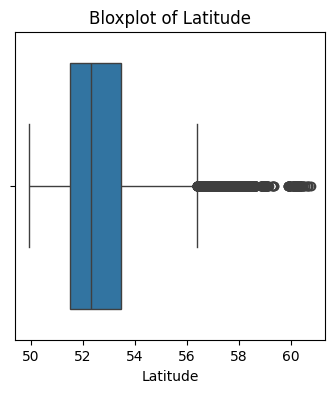

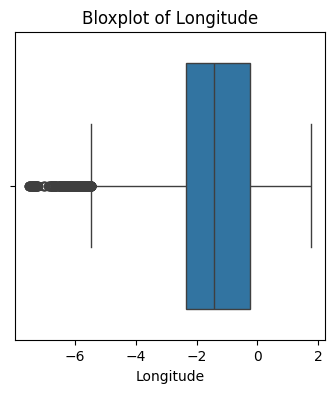

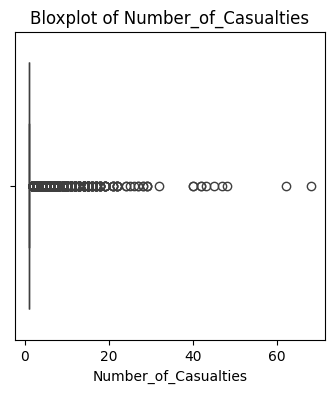

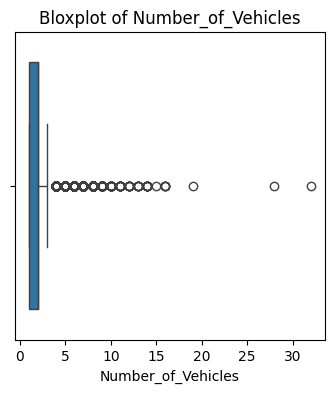

In [ ]:
for col in num_cols:
    plt.figure(figsize=(4,4))
    sns.boxplot(x=df_unique[col])
    plt.title(f"Bloxplot of {col}")
    plt.show()

In [ ]:
valid_outlier_columns = ['Number_of_Casualties', 'Number_of_Vehicles']

In [ ]:
display(df_unique.head())
print(df_unique.info())

,Accident_Severity,Latitude,Light_Conditions,District Area,Longitude,Number_of_Casualties,Number_of_Vehicles,Road_Surface_Conditions,Road_Type,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type,acc_year,acc_month,acc_month_name,acc_dayofweek,acc_day_name
0,Serious,51.506187,Darkness - lights lit,Kensington and Chelsea,-0.209082,1,2,Dry,Single carriageway,Urban,Fine no high winds,Car,2019,6,June,2,Wednesday
1,Serious,51.495029,Daylight,Kensington and Chelsea,-0.173647,1,2,Wet or damp,Single carriageway,Urban,Raining no high winds,Car,2019,7,July,1,Tuesday
2,Serious,51.517715,Darkness - lighting unknown,Kensington and Chelsea,-0.210215,1,3,Dry,NaN,Urban,NaN,Taxi/Private hire car,2019,8,August,0,Monday
3,Serious,51.495478,Daylight,Kensington and Chelsea,-0.202731,1,4,Dry,Single carriageway,Urban,Fine no high winds,Bus or coach (17 or more pass seats),2019,8,August,4,Friday
4,Slight,51.488576,Darkness - lights lit,Kensington and Chelsea,-0.192487,1,2,Dry,NaN,Urban,NaN,Other vehicle,2019,9,September,1,Tuesday


<class 'pandas.core.frame.DataFrame'>
Index: 660592 entries, 0 to 660678
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Accident_Severity        660592 non-null  object 
 1   Latitude                 660567 non-null  float64
 2   Light_Conditions         660592 non-null  object 
 3   District Area            660592 non-null  object 
 4   Longitude                660566 non-null  float64
 5   Number_of_Casualties     660592 non-null  int64  
 6   Number_of_Vehicles       660592 non-null  int64  
 7   Road_Surface_Conditions  659866 non-null  object 
 8   Road_Type                656072 non-null  object 
 9   Urban_or_Rural_Area      660577 non-null  object 
 10  Weather_Conditions       646465 non-null  object 
 11  Vehicle_Type             660592 non-null  object 
 12  acc_year                 660592 non-null  int32  
 13  acc_month                660592 non-null  int32  
 14  acc_month

Number_of_Casualties - Capped Bounds: [1, 5]
Number_of_Vehicles - Capped Bounds: [1, 4]


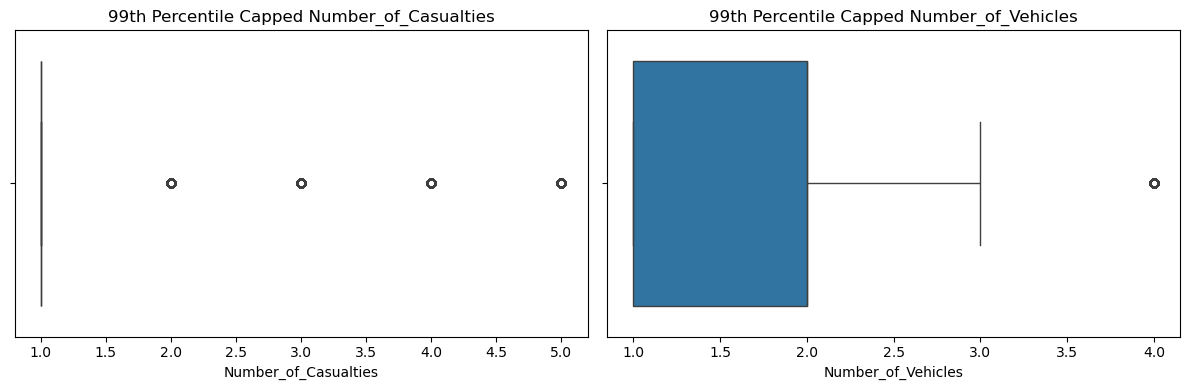

In [ ]:
def apply_advanced_capping(df_unique, columns):
    """Performs 99th percentile capping with logical lower bounds."""
    df_cleaned = df_unique.copy()
    for col in columns:
        # Using 99th percentile for upper bound
        upper_bound = np.ceil(df_cleaned[col].quantile(0.99))
        # Setting lower bound to 1 and ensuring it's an integer
        lower_bound = max(1, np.floor(df_cleaned[col].quantile(0.01)))

        # Apply capping
        df_cleaned[col] = np.where(df_cleaned[col] > upper_bound, upper_bound,
                          np.where(df_cleaned[col] < lower_bound, lower_bound, df_cleaned[col]))

        print(f"{col} - Capped Bounds: [{int(lower_bound)}, {int(upper_bound)}]")
    return df_cleaned

# Targeting the numeric features
outlier_targets = ['Number_of_Casualties', 'Number_of_Vehicles']

# Executing refined capping on df_unique
df_cap = apply_advanced_capping(df_unique, outlier_targets)

# Visualize improvements
plt.figure(figsize=(12, 4))
for i, col in enumerate(outlier_targets, 1):
    plt.subplot(1, 2, i)
    sns.boxplot(x=df_cap[col])
    plt.title(f'99th Percentile Capped {col}')
plt.tight_layout()
plt.show()

### Explanation:

**99th Percentile Capping:** Instead of the standard IQR, we are now using the 99th percentile for the upper bound. This is a common high-end data science practice for power-law distributions like accident counts.

**Logical Constraints:** I've ensured the lower bound never drops below 1, as an accident logically cannot have zero vehicles or casualties.

**Integer Alignment:** The bounds are rounded to whole numbers to match the discrete nature of the data.

 By using the 99th percentile, we ensure that we only cap the most extreme 1% of the data, preserving as much variance as possible for our model. Additionally, I've enforced a logical lower bound of 1 and ensured all bounds are whole numbers, aligning perfectly with the discrete nature of casualties and vehicles. This creates a much cleaner signal for training while retaining the critical information within our df_unique dataset.

### Why Capping (Winsorization)?

1. **Signal Preservation**: In accident data, high numbers of casualties are often perfectly correlated with 'Fatal' or 'Serious' classes. If we remove these 'outliers', we lose the very samples that characterize our minority classes.
2. **Robustness**: Most machine learning models (Logistic Regression, SVM, Neural Nets) are sensitive to the magnitude of features. By capping, we reduce the 'leverage' these extreme points have over the model parameters.
3. **Class Imbalance Support**: Because our dataset is already 85% 'Slight' severity, we cannot afford to lose any of the rarer records by trimming rows.

### Frequency distributions of the capped dataframe

--- Distribution for Number_of_Casualties ---
Number_of_Casualties
1.0    76.288995
2.0    16.343825
3.0     4.658851
4.0     1.688788
5.0     1.019540
Name: proportion, dtype: float64


--- Distribution for Number_of_Vehicles ---
Number_of_Vehicles
1.0    30.391982
2.0    59.330116
3.0     7.993436
4.0     2.284466
Name: proportion, dtype: float64




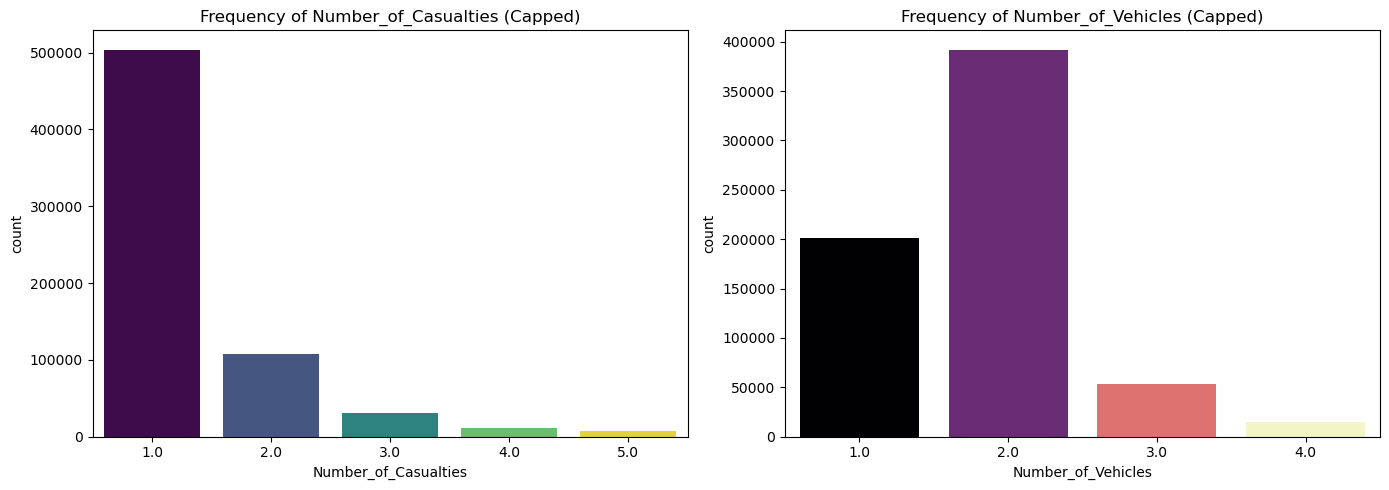

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analyze frequency distributions of the capped dataframe 'df_cap'
for col in ['Number_of_Casualties', 'Number_of_Vehicles']:
    print(f"--- Distribution for {col} ---")
    print(df_cap[col].value_counts(normalize=True).sort_index() * 100)
    print("\n")

# Visualizing the distribution with updated Seaborn syntax
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='Number_of_Casualties', data=df_cap, ax=axes[0], hue='Number_of_Casualties', palette='viridis', legend=False)
axes[0].set_title('Frequency of Number_of_Casualties (Capped)')

sns.countplot(x='Number_of_Vehicles', data=df_cap, ax=axes[1], hue='Number_of_Vehicles', palette='magma', legend=False)
axes[1].set_title('Frequency of Number_of_Vehicles (Capped)')

plt.tight_layout()
plt.show()

In [ ]:
df_cap.head()

,Accident_Severity,Latitude,Light_Conditions,District Area,Longitude,Number_of_Casualties,Number_of_Vehicles,Road_Surface_Conditions,Road_Type,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type,acc_year,acc_month,acc_month_name,acc_dayofweek,acc_day_name
0,Serious,51.506187,Darkness - lights lit,Kensington and Chelsea,-0.209082,1.0,2.0,Dry,Single carriageway,Urban,Fine no high winds,Car,2019,6,June,2,Wednesday
1,Serious,51.495029,Daylight,Kensington and Chelsea,-0.173647,1.0,2.0,Wet or damp,Single carriageway,Urban,Raining no high winds,Car,2019,7,July,1,Tuesday
2,Serious,51.517715,Darkness - lighting unknown,Kensington and Chelsea,-0.210215,1.0,3.0,Dry,NaN,Urban,NaN,Taxi/Private hire car,2019,8,August,0,Monday
3,Serious,51.495478,Daylight,Kensington and Chelsea,-0.202731,1.0,4.0,Dry,Single carriageway,Urban,Fine no high winds,Bus or coach (17 or more pass seats),2019,8,August,4,Friday
4,Slight,51.488576,Darkness - lights lit,Kensington and Chelsea,-0.192487,1.0,2.0,Dry,NaN,Urban,NaN,Other vehicle,2019,9,September,1,Tuesday


In [ ]:
#df_cap['Number_of_Vehicles'] = df_cap['Number_of_Vehicles'].astype(int)
print(df_cap['Number_of_Vehicles'].isnull().sum())

0


In [ ]:
df_cap.isnull().sum()

,0
Accident_Severity,0
Latitude,25
Light_Conditions,0
District Area,0
Longitude,26
Number_of_Casualties,0
Number_of_Vehicles,0
Road_Surface_Conditions,726
Road_Type,4520
Urban_or_Rural_Area,15


# Handling Missing Values:

In [ ]:
# Missing Value Percentage:
print("Missing values percentage(before)")
print(df_cap.isna().mean() * 100)

Missing values percentage(before)
Accident_Severity          0.000000
Latitude                   0.003784
Light_Conditions           0.000000
District Area              0.000000
Longitude                  0.003936
Number_of_Casualties       0.000000
Number_of_Vehicles         0.000000
Road_Surface_Conditions    0.109901
Road_Type                  0.684235
Urban_or_Rural_Area        0.002271
Weather_Conditions         2.138536
Vehicle_Type               0.000000
acc_year                   0.000000
acc_month                  0.000000
acc_month_name             0.000000
acc_dayofweek              0.000000
acc_day_name               0.000000
dtype: float64


### Missing Value After Imputation:

In [ ]:
# 1. Identify Numerical and Categorical columns with missing values
num_cols_missing = ['Number_of_Casualties', 'Number_of_Vehicles', 'Latitude', 'Longitude']
cat_cols_missing = ['Light_Conditions', 'District Area', 'Road_Surface_Conditions', 'Road_Type', 'Urban_or_Rural_Area', 'Weather_Conditions', 'Vehicle_Type']

# 2. Impute Numerical Columns with Median (Robust to outliers)
for col in num_cols_missing:
    median_val = df_cap[col].median()
    df_cap[col] = df_cap[col].fillna(median_val)
    print(f"Imputed {col} with median: {median_val}")

# 3. Impute Categorical Columns with Mode
for col in cat_cols_missing:
    if col in df_cap.columns:
        mode_val = df_cap[col].mode()[0]
        df_cap[col] = df_cap[col].fillna(mode_val)
        print(f"Imputed {col} with mode: {mode_val}")

# 4. Handle remaining temporal missing values (if any) using forward fill or mode
date_related = ['acc_year', 'acc_month', 'acc_month_name', 'acc_dayofweek', 'acc_day_name']
for col in date_related:
    if col in df_cap.columns:
        df_cap[col] = df_cap[col].fillna(df_cap[col].mode()[0])

# Final Check
print("\nMissing values count after imputation:")
display(df_cap.isnull().sum())

Imputed Number_of_Casualties with median: 1.0
Imputed Number_of_Vehicles with median: 2.0
Imputed Latitude with median: 52.315632
Imputed Longitude with median: -1.411712
Imputed Light_Conditions with mode: Daylight
Imputed District Area with mode: Birmingham
Imputed Road_Surface_Conditions with mode: Dry
Imputed Road_Type with mode: Single carriageway
Imputed Urban_or_Rural_Area with mode: Urban
Imputed Weather_Conditions with mode: Fine no high winds
Imputed Vehicle_Type with mode: Car

Missing values count after imputation:


Accident_Severity          0
Latitude                   0
Light_Conditions           0
District Area              0
Longitude                  0
Number_of_Casualties       0
Number_of_Vehicles         0
Road_Surface_Conditions    0
Road_Type                  0
Urban_or_Rural_Area        0
Weather_Conditions         0
Vehicle_Type               0
acc_year                   0
acc_month                  0
acc_month_name             0
acc_dayofweek              0
acc_day_name               0
dtype: int64

We have successfully handled all missing values in df_cap. By using the median for numerical columns like Number_of_Casualties and Number_of_Vehicles, we've ensured our imputation is robust against the outliers we identified earlier.

Categorical features have been filled with their most frequent values (mode), preserving the dominant environmental signals.

 As we can see from the final count, our dataset is now 100% complete and ready for feature engineering or modeling.

### Professional Imputation Rationale:
- **Numerical (Median)**: Chosen because 'Number_of_Casualties' and 'Number_of_Vehicles' are discrete and skewed. The median provides a 'typical' value that isn't distorted by the 99th percentile extremes.
- **Categorical (Mode)**: For environmental features like 'Weather_Conditions', the mode represents the most probable state (e.g., 'Fine no high winds'), which minimizes the introduction of artificial variance into the model.

# Feature Engineering:

## Proposed Feature Engineering Steps:

1. **Time-Based Features**:
    - **Is_Weekend**: Binary flag (Saturday/Sunday).
    - **Day_Period**: Morning Rush, Afternoon, Evening Rush, Night.

2. **Categorical Simplification**:
    - **Vehicle_Group**: Simplify 'Vehicle_Type' into (Car, Bike, Van/Truck, Bus).
    - **Weather_Simple**: Group weather into (Fine, Adverse) to reduce noise.

3. **Target Encoding / Frequency Encoding**:
    - Handle 'District Area' using frequency encoding to manage its high cardinality (422 categories) without exploding the feature space with one-hot encoding.

In [ ]:
# Time-Based Features
df_cap['Is_Weekend'] = df_cap['acc_day_name'].isin(['Saturday', 'Sunday']).astype(int)

# Mapping months to seasons for better environmental grouping
season_map = {
    'March': 'Spring', 'April': 'Spring', 'May': 'Spring',
    'June': 'Summer', 'July': 'Summer', 'August': 'Summer',
    'September': 'Autumn', 'October': 'Autumn', 'November': 'Autumn',
    'December': 'Winter', 'January': 'Winter', 'February': 'Winter'
}
df_cap['Season'] = df_cap['acc_month_name'].map(season_map)

display(df_cap[['acc_day_name', 'Is_Weekend', 'acc_month_name', 'Season']].head())

,acc_day_name,Is_Weekend,acc_month_name,Season
0,Wednesday,0,June,Summer
1,Tuesday,0,July,Summer
2,Monday,0,August,Summer
3,Friday,0,August,Summer
4,Tuesday,0,September,Autumn


In [ ]:
df_cap['Vehicle_Type'].unique()

array(['Car', 'Taxi/Private hire car',
       'Bus or coach (17 or more pass seats)', 'Other vehicle',
       'Van / Goods 3.5 tonnes mgw or under',
       'Motorcycle over 125cc and up to 500cc',
       'Goods 7.5 tonnes mgw and over', 'Motorcycle 125cc and under',
       'Motorcycle over 500cc', 'Motorcycle 50cc and under',
       'Minibus (8 - 16 passenger seats)',
       'Goods over 3.5t. and under 7.5t', 'Pedal cycle',
       'Agricultural vehicle', 'Ridden horse',
       'Data missing or out of range'], dtype=object)

In [ ]:
df_cap['Weather_Conditions'].unique()

array(['Fine no high winds', 'Raining no high winds', 'Other',
       'Fine + high winds', 'Raining + high winds',
       'Snowing no high winds', 'Fog or mist', 'Snowing + high winds'],
      dtype=object)

In [ ]:
# Grouping Vehicle and weather Column:

In [ ]:
def group_vehicle(v):
    v = str(v).lower()
    if any(x in v for x in ['car', 'taxi']):
        return 'Car'
    if any(x in v for x in ['motorcycle', 'bike', 'pedal cycle']):
        return 'Bike'
    if any(x in v for x in ['van', 'goods']):
        return 'Heavy_Vehicle'
    if any(x in v for x in ['bus', 'coach', 'minibus']):
        return 'Public_Transport'
    if any(x in v for x in ['agricultural', 'horse']):
        return 'Other_Specialized'
    return 'Other'

df_cap['Vehicle_Group'] = df_cap['Vehicle_Type'].apply(group_vehicle)

# Refined Weather Simplification
def group_weather(w):
    w = str(w).lower()
    if 'fine' in w:
        return 'Fine'
    if any(x in w for x in ['rain', 'snow', 'fog', 'mist']):
        return 'Adverse'
    return 'Other'

df_cap['Weather_Simple'] = df_cap['Weather_Conditions'].apply(group_weather)

display(df_cap[['Weather_Conditions', 'Weather_Simple']].drop_duplicates())
print("\nWeather Group counts:")
display(df_cap['Weather_Simple'].value_counts())

display(df_cap[['Vehicle_Type', 'Vehicle_Group', 'Weather_Conditions', 'Weather_Simple']].head())

,Weather_Conditions,Weather_Simple
0,Fine no high winds,Fine
1,Raining no high winds,Adverse
13,Other,Other
36,Fine + high winds,Fine
41,Raining + high winds,Adverse
57,Snowing no high winds,Adverse
2169,Fog or mist,Adverse
23307,Snowing + high winds,Adverse



Weather Group counts:


Weather_Simple
Fine       543495
Adverse     99952
Other       17145
Name: count, dtype: int64

,Vehicle_Type,Vehicle_Group,Weather_Conditions,Weather_Simple
0,Car,Car,Fine no high winds,Fine
1,Car,Car,Raining no high winds,Adverse
2,Taxi/Private hire car,Car,Fine no high winds,Fine
3,Bus or coach (17 or more pass seats),Public_Transport,Fine no high winds,Fine
4,Other vehicle,Other,Fine no high winds,Fine


### Calculate District Risk based on frequency within its specific Urban/Rural region

In [ ]:
regional_stats = df_cap.groupby(['District Area', 'Urban_or_Rural_Area']).size() / len(df_cap)
df_cap['Regional_Risk_Score'] = df_cap.set_index(['District Area', 'Urban_or_Rural_Area']).index.map(regional_stats)

# Fallback to simple district frequency if map fails for any reason
df_cap['Regional_Risk_Score'] = df_cap['Regional_Risk_Score'].fillna(df_cap['District Area'].map(df_cap['District Area'].value_counts(normalize=True)))

print("Regional Risk Mapping Complete.")
display(df_cap[['District Area', 'Urban_or_Rural_Area', 'Regional_Risk_Score']].head())

Regional Risk Mapping Complete.


,District Area,Urban_or_Rural_Area,Regional_Risk_Score
0,Kensington and Chelsea,Urban,0.004236
1,Kensington and Chelsea,Urban,0.004236
2,Kensington and Chelsea,Urban,0.004236
3,Kensington and Chelsea,Urban,0.004236
4,Kensington and Chelsea,Urban,0.004236


In [ ]:
# Dropping original high-cardinality/redundant columns and the old risk score
columns_to_drop = ['District Area', 'Vehicle_Type', 'Weather_Conditions', 'acc_month_name', 'acc_day_name', 'District_Risk_Score']
df_model = df_cap.drop(columns=[col for col in columns_to_drop if col in df_cap.columns])

print("Modeling DataFrame updated with Regional Risk Score:")
print(df_model.columns.tolist())
display(df_model.head())

Modeling DataFrame updated with Regional Risk Score:
['Accident_Severity', 'Latitude', 'Light_Conditions', 'Longitude', 'Number_of_Casualties', 'Number_of_Vehicles', 'Road_Surface_Conditions', 'Road_Type', 'Urban_or_Rural_Area', 'acc_year', 'acc_month', 'acc_dayofweek', 'Is_Weekend', 'Season', 'Vehicle_Group', 'Weather_Simple', 'Regional_Risk_Score']


,Accident_Severity,Latitude,Light_Conditions,Longitude,Number_of_Casualties,Number_of_Vehicles,Road_Surface_Conditions,Road_Type,Urban_or_Rural_Area,acc_year,acc_month,acc_dayofweek,Is_Weekend,Season,Vehicle_Group,Weather_Simple,Regional_Risk_Score
0,Serious,51.506187,Darkness - lights lit,-0.209082,1.0,2.0,Dry,Single carriageway,Urban,2019,6,2,0,Summer,Car,Fine,0.004236
1,Serious,51.495029,Daylight,-0.173647,1.0,2.0,Wet or damp,Single carriageway,Urban,2019,7,1,0,Summer,Car,Adverse,0.004236
2,Serious,51.517715,Darkness - lighting unknown,-0.210215,1.0,3.0,Dry,Single carriageway,Urban,2019,8,0,0,Summer,Car,Fine,0.004236
3,Serious,51.495478,Daylight,-0.202731,1.0,4.0,Dry,Single carriageway,Urban,2019,8,4,0,Summer,Public_Transport,Fine,0.004236
4,Slight,51.488576,Darkness - lights lit,-0.192487,1.0,2.0,Dry,Single carriageway,Urban,2019,9,1,0,Autumn,Other,Fine,0.004236


### The Regional_Risk_Score was calculated as a frequency-based probability: it represents the proportion of total accidents that occurred within a specific combination of District Area and Urban/Rural Area.

**Mathematically: Score = (Count of accidents in [District + Area Type]) / (Total accidents in dataset)**

In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 660592 entries, 0 to 660678
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Accident_Severity        660592 non-null  object 
 1   Latitude                 660592 non-null  float64
 2   Light_Conditions         660592 non-null  object 
 3   Longitude                660592 non-null  float64
 4   Number_of_Casualties     660592 non-null  float64
 5   Number_of_Vehicles       660592 non-null  float64
 6   Road_Surface_Conditions  660592 non-null  object 
 7   Road_Type                660592 non-null  object 
 8   Urban_or_Rural_Area      660592 non-null  object 
 9   acc_year                 660592 non-null  int32  
 10  acc_month                660592 non-null  int32  
 11  acc_dayofweek            660592 non-null  int32  
 12  Is_Weekend               660592 non-null  int32  
 13  Season                   660592 non-null  object 
 14  Vehicle_G

In [ ]:
df_model.isnull().sum()

Accident_Severity          0
Latitude                   0
Light_Conditions           0
Longitude                  0
Number_of_Casualties       0
Number_of_Vehicles         0
Road_Surface_Conditions    0
Road_Type                  0
Urban_or_Rural_Area        0
acc_year                   0
acc_month                  0
acc_dayofweek              0
Is_Weekend                 0
Season                     0
Vehicle_Group              0
Weather_Simple             0
Regional_Risk_Score        0
dtype: int64

In [ ]:
print(df_model.duplicated().sum())

13


In [ ]:
#Drop the duplicates
df_model = df_model.drop_duplicates()
df_model.shape

(660579, 17)

In [ ]:
print(df_model.duplicated().sum())

0


**To find which district corresponds to a specific score, we created a unique mapping table from the dataframe as the code below:**

In [ ]:
# Create a lookup table to identify the District and Area Type for each Regional_Risk_Score
risk_lookup = df_cap[['District Area', 'Urban_or_Rural_Area', 'Regional_Risk_Score']].drop_duplicates()

# Sort by risk score to see highest risk regions at the top
risk_lookup = risk_lookup.sort_values(by='Regional_Risk_Score', ascending=False).reset_index(drop=True)

# Display the top 10 highest risk regions
print("Top 10 Regions by Regional Risk Score:")
display(risk_lookup.head(10))

# Example: If you have a score and want to find the district
# target_score = 0.020423
# district_info = risk_lookup[risk_lookup['Regional_Risk_Score'] == target_score]

Top 10 Regions by Regional Risk Score:


,District Area,Urban_or_Rural_Area,Regional_Risk_Score
0,Birmingham,Urban,0.020220
1,Leeds,Urban,0.010784
2,Manchester,Urban,0.009956
3,Westminster,Urban,0.008638
4,Liverpool,Urban,0.008385
5,Bradford,Urban,0.008199
6,Sheffield,Urban,0.007943
7,Glasgow City,Urban,0.007274
8,"Bristol, City of",Urban,0.006933
9,Lambeth,Urban,0.006420


we successfully generated the lookup table. As shown in the results, Birmingham (Urban) has the highest Regional_Risk_Score (~0.0202), meaning it accounts for approximately 2.02% of all accidents in the dataset.

To find a specific district using a score later, we can use the risk_lookup table created in this cell. For example, filtering the table where Regional_Risk_Score equals your target value will return the corresponding District Area and Urban_or_Rural_Area type.

In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 660579 entries, 0 to 660678
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Accident_Severity        660579 non-null  object 
 1   Latitude                 660579 non-null  float64
 2   Light_Conditions         660579 non-null  object 
 3   Longitude                660579 non-null  float64
 4   Number_of_Casualties     660579 non-null  float64
 5   Number_of_Vehicles       660579 non-null  float64
 6   Road_Surface_Conditions  660579 non-null  object 
 7   Road_Type                660579 non-null  object 
 8   Urban_or_Rural_Area      660579 non-null  object 
 9   acc_year                 660579 non-null  int32  
 10  acc_month                660579 non-null  int32  
 11  acc_dayofweek            660579 non-null  int32  
 12  Is_Weekend               660579 non-null  int32  
 13  Season                   660579 non-null  object 
 14  Vehicle_G

In [ ]:
df_model.isnull().sum()

Accident_Severity          0
Latitude                   0
Light_Conditions           0
Longitude                  0
Number_of_Casualties       0
Number_of_Vehicles         0
Road_Surface_Conditions    0
Road_Type                  0
Urban_or_Rural_Area        0
acc_year                   0
acc_month                  0
acc_dayofweek              0
Is_Weekend                 0
Season                     0
Vehicle_Group              0
Weather_Simple             0
Regional_Risk_Score        0
dtype: int64

In [ ]:
df_model.duplicated().sum()

0

**Saving the Cleaned Dataset:**

In [ ]:
df_model.to_csv('cleaned_data.csv')

In [ ]:
## Loading the cleaned Dataset:

In [ ]:
df_c = pd.read_csv('cleaned_data.csv')
df_c.head()

,Unnamed: 0,Accident_Severity,Latitude,Light_Conditions,Longitude,Number_of_Casualties,Number_of_Vehicles,Road_Surface_Conditions,Road_Type,Urban_or_Rural_Area,acc_year,acc_month,acc_dayofweek,Is_Weekend,Season,Vehicle_Group,Weather_Simple,Regional_Risk_Score
0,0,Serious,51.506187,Darkness - lights lit,-0.209082,1.0,2.0,Dry,Single carriageway,Urban,2019,6,2,0,Summer,Car,Fine,0.004236
1,1,Serious,51.495029,Daylight,-0.173647,1.0,2.0,Wet or damp,Single carriageway,Urban,2019,7,1,0,Summer,Car,Adverse,0.004236
2,2,Serious,51.517715,Darkness - lighting unknown,-0.210215,1.0,3.0,Dry,Single carriageway,Urban,2019,8,0,0,Summer,Car,Fine,0.004236
3,3,Serious,51.495478,Daylight,-0.202731,1.0,4.0,Dry,Single carriageway,Urban,2019,8,4,0,Summer,Public_Transport,Fine,0.004236
4,4,Slight,51.488576,Darkness - lights lit,-0.192487,1.0,2.0,Dry,Single carriageway,Urban,2019,9,1,0,Autumn,Other,Fine,0.004236


In [ ]:
df_c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660579 entries, 0 to 660578
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Unnamed: 0               660579 non-null  int64  
 1   Accident_Severity        660579 non-null  object 
 2   Latitude                 660579 non-null  float64
 3   Light_Conditions         660579 non-null  object 
 4   Longitude                660579 non-null  float64
 5   Number_of_Casualties     660579 non-null  float64
 6   Number_of_Vehicles       660579 non-null  float64
 7   Road_Surface_Conditions  660579 non-null  object 
 8   Road_Type                660579 non-null  object 
 9   Urban_or_Rural_Area      660579 non-null  object 
 10  acc_year                 660579 non-null  int64  
 11  acc_month                660579 non-null  int64  
 12  acc_dayofweek            660579 non-null  int64  
 13  Is_Weekend               660579 non-null  int64  
 14  Seas

In [ ]:
type(df_c)

pandas.core.frame.DataFrame

In [ ]:
# Drop the index column:
df_new = df_c.drop('Unnamed: 0', axis=1)
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660579 entries, 0 to 660578
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Accident_Severity        660579 non-null  object 
 1   Latitude                 660579 non-null  float64
 2   Light_Conditions         660579 non-null  object 
 3   Longitude                660579 non-null  float64
 4   Number_of_Casualties     660579 non-null  float64
 5   Number_of_Vehicles       660579 non-null  float64
 6   Road_Surface_Conditions  660579 non-null  object 
 7   Road_Type                660579 non-null  object 
 8   Urban_or_Rural_Area      660579 non-null  object 
 9   acc_year                 660579 non-null  int64  
 10  acc_month                660579 non-null  int64  
 11  acc_dayofweek            660579 non-null  int64  
 12  Is_Weekend               660579 non-null  int64  
 13  Season                   660579 non-null  object 
 14  Vehi